# 🪐 FuzzyCore: A Comprehensive Guide to Giant Planet Interior Modeling

Welcome to **FuzzyCore**, a modular numerical framework designed to solve the interior structure of giant planets and sub-Neptunes. 

Traditional models assume a sharp physical boundary between a solid rock/ice core and a homogeneous gaseous envelope. However, modern planetary science is moving towards a "Fuzzy Core" paradigm, where heavy elements are suspended in dilute compositional gradients. This framework is specifically built to map the degeneracies between compact solid cores and these highly extended, metal-rich envelopes.

---

## 1. The Physics and Mathematics

At its heart, `fuzzycore` is a 1D hydrostatic integrator. It builds a planet from the inside out (or outside in, depending on the zone) by solving two fundamental differential equations of planetary structure:

$$dP/dr=-\rho g=-\rho \frac{Gm(r)}{r^2}$$
$$dm/dr=4\pi r^2\rho$$

The solver steps through the planet, evaluating these equations at each layer. To do this, it needs the density $\rho$ at any given Pressure ($P$) and Temperature ($T$), which is provided by the Equation of State (EOS).

### 1.1 Mixed Equation of State (EOS)
Instead of forcing the core to be pure rock or pure iron, `fuzzycore` utilizes an **additive volume mixing law**. For a given iron mass fraction ($X_{Fe}$), the density of the core is calculated as:

$$\frac{1}{\rho_{mix}(P,T)}=\frac{X_{Fe}}{\rho_{Fe}(P,T)}+\frac{1-X_{Fe}}{\rho_{Rock}(P,T)}$$

This prevents unphysical "floating cores" that can occur if high-pressure water/ice becomes denser than uncompressed silicates. 

### 1.2 The Compositional Staircase
To model a "fuzzy" core, the code distributes heavy elements ($Z$) into the hydrogen-helium envelope following a Gaussian decay profile. 

Instead of a smooth gradient, the framework discretizes this into a **staircase** of distinct compositional layers. This mimics the physical barriers to convection caused by mean molecular weight gradients (Double-Diffusive Convection). Heat must cross these "entropy jumps", acting as a massive thermal blanket that forces the deep interior to become fiercely hot, expanding the planet's radius.

---

## 2. Code Architecture & The KD-Tree Stepper

The framework is highly modular, split into distinct physical engines:
* `eos.py`: Manages the loading, caching, and interpolation of raw data tables (Hydrogen, Helium, Water, Rock, Iron).
* `physics.py`: Contains the core integrators (`integrate_core`, `build_staircase_envelope`) and the overarching structural routers.
* `solver.py`: Houses the root-finding algorithm (`brentq`) that dynamically guesses the central pressure required to hit your target mass.

### The KD-Tree Adiabat Stepper
Building the envelope requires tracing an adiabat (a path of constant entropy, $S$). Standard 1D interpolations often fail at jagged phase transitions. 

To solve this, `fuzzycore` uses a `RobustAdiabatStepper`. It queries a 3D KD-Tree of the local phase space $(P,T,S)$ to find the 10 closest physical points. It then performs a local linear least-squares regression:

$$S(P,T)\approx aP+bT+c$$

By algebraically solving this regression plane for $T$ given a target $P$ and $S$, the code can step smoothly through violently non-linear phase spaces without crashing.

---
## 3. Concrete Usage Examples

Let's use the code to build planetary interiors. First, we will build a standard gas giant with a sharp core boundary. By setting `sigma_val` to $0.0$, we force the envelope to be fully convective and perfectly mixed.

In [1]:
import fuzzycore.solver as solver
import fuzzycore.constants as c
import fuzzycore.utils as utils

# 1. Define the physical parameters
params = {
    'P_surf': 1.0,               # Surface pressure (bar)
    'T_surf': 500.0,             # Surface temperature (K)
    'M_core': 15.0 * c.M_EARTH,  # 15 Earth-mass solid core
    'iron_fraction': 0.33,       # Earth-like rock/iron ratio
    'z_base': 0.02,              # Solar-like metallicity in the envelope
    
    # Setting sigma to 0.0 creates a purely adiabatic, well-mixed envelope!
    'sigma_val': 0.0,            
    'z_profile': utils.generate_gaussian_z_profile(sigma=0.0, z_base=0.02),
    'debug': True
}

# 2. Fire the solver!
target_mass = 1.0 * c.M_JUPITER

# The dummy lock is required for single-threaded notebook execution
with utils.DummyLock() as lock:
    result = solver.solve_structure(
        target_val=target_mass,
        params=params,
        mode='mass',
        trial_id="sharp_jupiter",
        csv_file="solver_tracking.csv",
        write_lock=lock
    )

print(f"Convergence successful! Total Radius: {result['R_total'] / c.R_JUPITER:.2f} R_Jup")

--- Loading Raw EOS Tables (From Disk) ---
  > Loading Hydrogen...
  > Loading Helium...
  > Loading Water...
  > Loading Rock...
  > Loading Iron...
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Trial sharp_jupiter: Global scan initiated
  [Solver] logPc 6.50: Integration returned None
  [Solver] logPc 7.00: Integration returned None
[START] Pc=3.16e+07 -> P_int=1.09e+07 -> T_int=26311.2 K
[SUCCESS] M=0.534 Mj
  [Debug] sharp_jupiter logPc: 7.50 -> Mass: 0.534 Mj
[START] Pc=1.00e+08 -> P_int=5.86e+07 -> T_int=44532.0 K
[SUCCESS] M=1.505 Mj
  [Debug] sharp_jupiter logPc: 8.00 -> Mass: 1.505 Mj
[START] Pc=3.16e+08 -> P_int=2.29e+08 -> T_int=74988.7 K
[SUCCESS] M=3.076 Mj
  [Debug] sharp_jupiter logPc: 8.50 -> Mass: 3.076 Mj
[START] Pc=1.00e+09 -> P_int=8.09e+08 -> T_int=119572.0 K
[SUCC

### Example 2: The Inflated "Fuzzy" Sub-Neptune
To see the dramatic thermal blanketing effect of a dilute core, we distribute the heavy elements into the envelope using a wide Gaussian profile (`sigma_val = 0.30`). This breaks the convection into a staircase, trapping heat inside.

In [2]:
# 1. Define the Fuzzy parameters
fuzzy_params = params.copy()
fuzzy_params['sigma_val'] = 0.30

# Generate a 100-layer compositional staircase
fuzzy_params['z_profile'] = utils.generate_gaussian_z_profile(
    n_layers=100, 
    sigma=0.30, 
    z_base=0.02, 
    z_core=0.99
)

# 2. Solve for an 8.0 Earth-mass Sub-Neptune
target_mass_subnep = 8.0 * c.M_EARTH

with utils.DummyLock() as lock:
    fuzzy_result = solver.solve_structure(
        target_val=target_mass_subnep,
        params=fuzzy_params,
        mode='mass',
        trial_id="fuzzy_subnep",
        csv_file="solver_tracking.csv",
        write_lock=lock
    )

print(f"Fuzzy Planet Radius: {fuzzy_result['R_total'] / c.R_EARTH:.2f} R_Earth")

Trial fuzzy_subnep: Global scan initiated
  [Solver] logPc 6.50: Integration returned None
  [Solver] logPc 7.00: Integration returned None
[START] Pc=3.16e+07 -> P_int=1.06e+07 -> T_int=20622.6 K
[SUCCESS] M=0.125 Mj
  [Debug] fuzzy_subnep logPc: 7.50 -> Mass: 0.125 Mj
[START] Pc=1.00e+08 -> P_int=5.82e+07 -> T_int=38080.4 K
[SUCCESS] M=0.315 Mj
  [Debug] fuzzy_subnep logPc: 8.00 -> Mass: 0.315 Mj
[START] Pc=3.16e+08 -> P_int=2.29e+08 -> T_int=57882.3 K
[SUCCESS] M=0.643 Mj
  [Debug] fuzzy_subnep logPc: 8.50 -> Mass: 0.643 Mj
[START] Pc=1.00e+09 -> P_int=8.09e+08 -> T_int=85269.5 K
[SUCCESS] M=1.184 Mj
  [Debug] fuzzy_subnep logPc: 9.00 -> Mass: 1.184 Mj
[START] Pc=3.16e+09 -> P_int=3.13e+09 -> T_int=140499.5 K
[SUCCESS] M=3.292 Mj
  [Debug] fuzzy_subnep logPc: 9.50 -> Mass: 3.292 Mj
[START] Pc=1.00e+10 -> P_int=9.97e+09 -> T_int=230035.1 K
[SUCCESS] M=5.747 Mj
  [Debug] fuzzy_subnep logPc: 10.00 -> Mass: 5.747 Mj
[START] Pc=3.16e+10 -> P_int=3.16e+10 -> T_int=397407.8 K
[SUCCESS] M=9

### Example 3: Extracting Cooling Rates ($dS/dt$)
The framework automatically post-processes the thermodynamics to calculate the macroscopic entropy loss rate (cooling rate) of the planet. This is vital for evolutionary tracking.

In [3]:
# The inverse cooling rate is automatically calculated and attached to the results dict!
dt_ds_raw = fuzzy_result['dt_ds_total']

# Convert from the raw integral (seconds per J/K/kg) to a physical rate
if dt_ds_raw > 0:
    cooling_rate = 1.0 / dt_ds_raw
    print(f"Cooling Rate (dS/dt): {cooling_rate:.2e} J/K/kg/s")
else:
    print("Planet is not cooling natively.")
    
# You can also see how much each compositional layer contributes to the thermal inertia:
layer_breakdown = fuzzy_result['dt_ds_layers']
print("Layer Breakdown:", layer_breakdown)

Planet is not cooling natively.
Layer Breakdown: {0.02: -492.41503906256, 0.02207987151470585: -38114.19188464398, 0.09867244782904941: -336302.73640953674, 0.28003261788887723: -2308376.755666047, 0.5810178836064374: -73619.5483208488, 1.0: -26099976040.807392}


---
## 4. Visualization & Diagnostics

Once you have a converged `result` dictionary, `fuzzycore` provides native plotting tools to dissect the interior. 

* `plot_diagnostics`: Generates a 6-panel grid showing Density, Mass, Temperature, Z, P-T, and Entropy. It automatically shades the Rock and Water zones.
* `plot_trajectory_on_eos`: Maps the exact P-T trajectory over the local Equation of State grid points.

Figure saved to: ../figures/my_fuzzy_planet.pdf


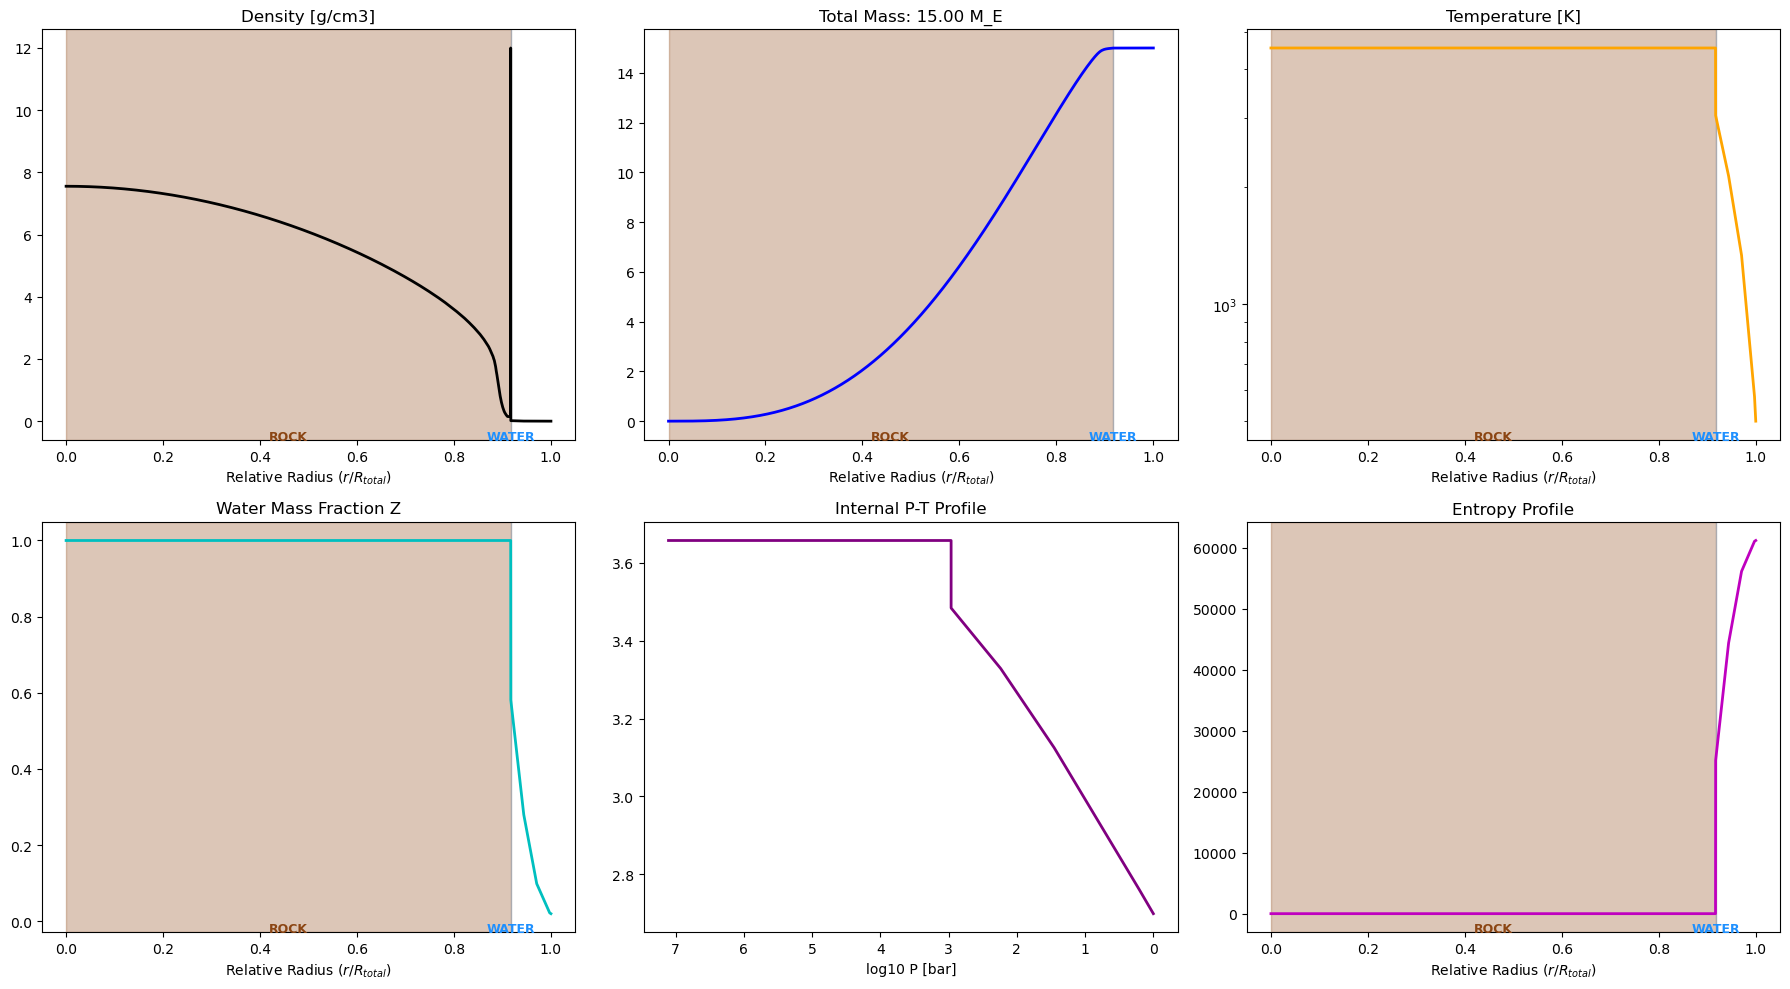

Figure saved to: ../figures/eos_path.pdf


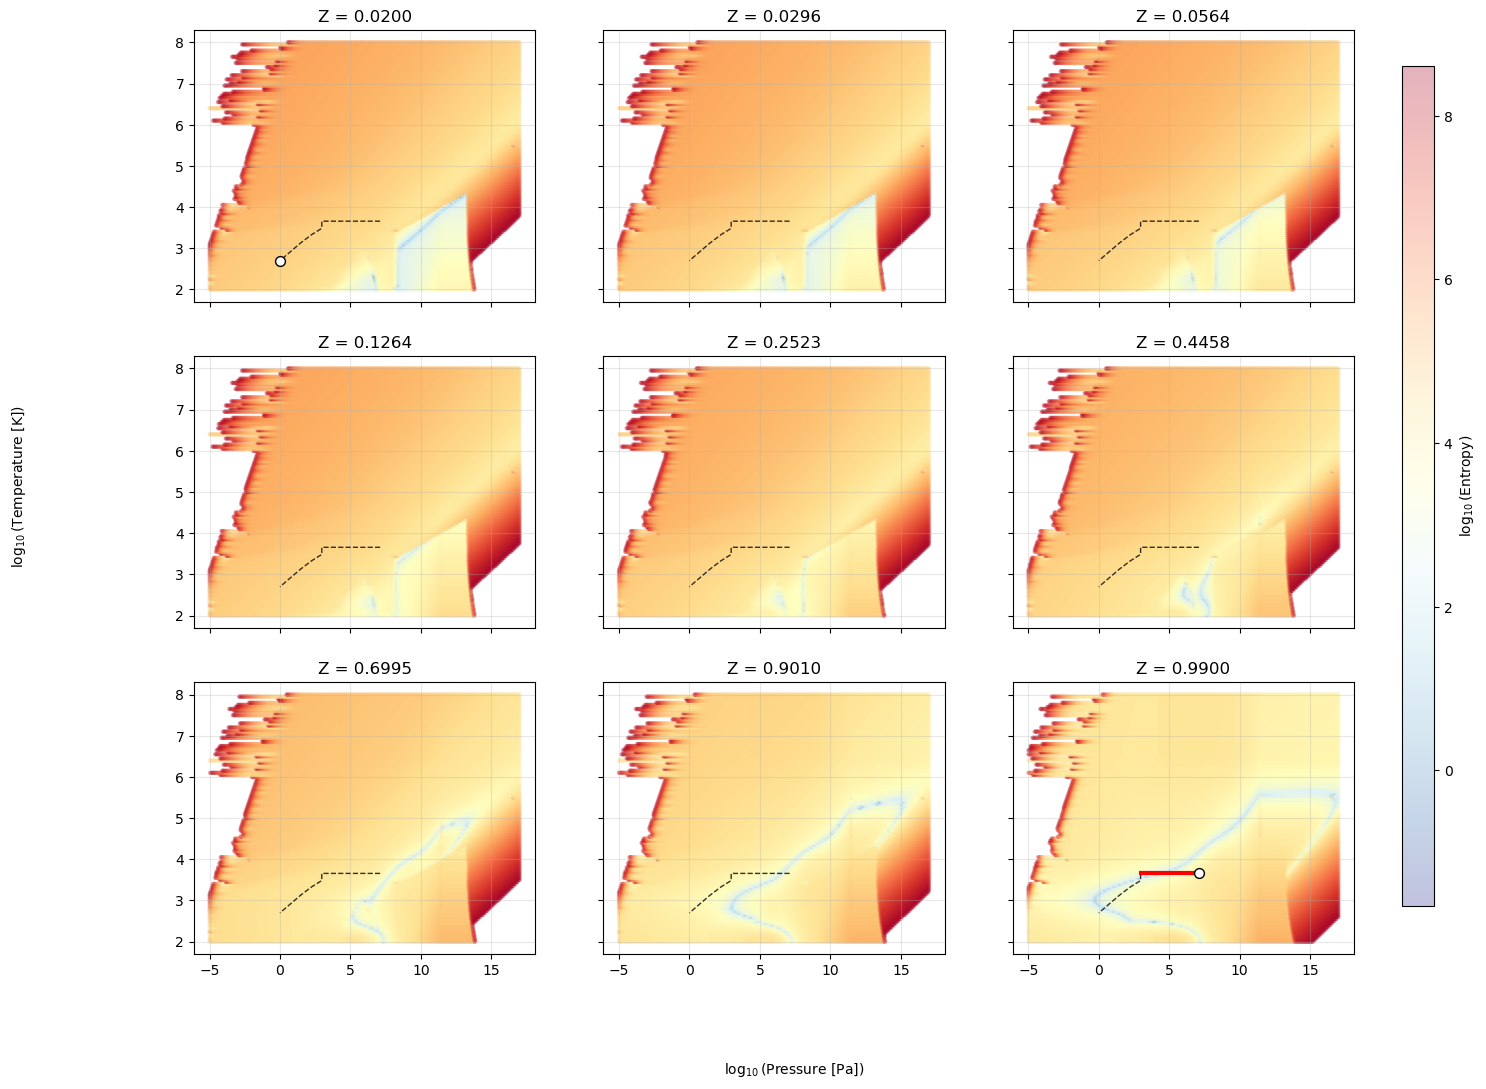

In [4]:
import fuzzycore.plotting as fplot

# Plot the 6-panel interior diagnostic
fplot.plot_diagnostics(fuzzy_result, save_name="my_fuzzy_planet")

# Plot the EOS phase space trajectory
fplot.plot_trajectory_on_eos(fuzzy_result, fuzzy_params, save_name="eos_path")